# WTI vs Brent Crude Oil Price Forecasting

This notebook compares WTI and Brent crude oil daily spot prices and tests whether
ARIMA or a Random Forest model can meaningfully outperform a naive baseline when
forecasting WTI prices 30 days ahead.

**Data:** daily WTI and Brent spot prices (`data/wti-daily.csv`, `data/brent-daily.csv`).

See the repo README for the full write-up, results summary, and limitations.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (12, 4)

## 2. Load and prepare data

In [2]:
wti = pd.read_csv('../data/wti-daily.csv')
brent = pd.read_csv('../data/brent-daily.csv')

wti['Date'] = pd.to_datetime(wti['Date'])
brent['Date'] = pd.to_datetime(brent['Date'])

wti = wti.set_index('Date')
brent = brent.set_index('Date')

wti.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 10205 entries, 1986-01-02 to 2026-07-20
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   10205 non-null  float64
dtypes: float64(1)
memory usage: 159.5 KB


## 3. Merge and align series

WTI and Brent are recorded on slightly different trading calendars, so an outer
merge on date is used to preserve all observations before handling missing values.

In [3]:
oil = pd.merge(wti, brent, left_index=True, right_index=True, how='outer', suffixes=('_wti', '_brent'))
oil = oil.sort_index()
oil = oil.rename(columns={'Price_wti': 'wti', 'Price_brent': 'brent'})
print(oil.shape)
oil.head()

(10382, 2)


,wti,brent
Date,,
1986-01-02,25.56,NaN
1986-01-03,26.00,NaN
1986-01-06,26.53,NaN
1986-01-07,25.85,NaN
1986-01-08,25.87,NaN


## 4. Handle missing values

Short gaps (up to 5 trading days) are forward-filled — reasonable for a slow-moving
daily price series. Remaining gaps, mostly from calendar mismatches early in the
Brent series (which starts later than WTI), are dropped rather than filled, to
avoid inventing price data over longer stretches.

In [4]:
print("Missing before fill:")
print(oil.isna().sum())

oil[['wti', 'brent']] = oil[['wti', 'brent']].ffill(limit=5)

print("\nMissing after limited forward-fill:")
print(oil.isna().sum())

oil = oil.dropna()
print("\nFinal shape after dropping remaining gaps:", oil.shape)

Missing before fill:
wti      177
brent    445
dtype: int64

Missing after limited forward-fill:
wti        0
brent    346
dtype: int64

Final shape after dropping remaining gaps: (10036, 2)


## 5. Feature exploration: spread, returns, volatility

The Brent–WTI spread, daily returns, and rolling volatility are examined to
understand how the two benchmarks move relative to each other and how volatile
WTI has been historically.

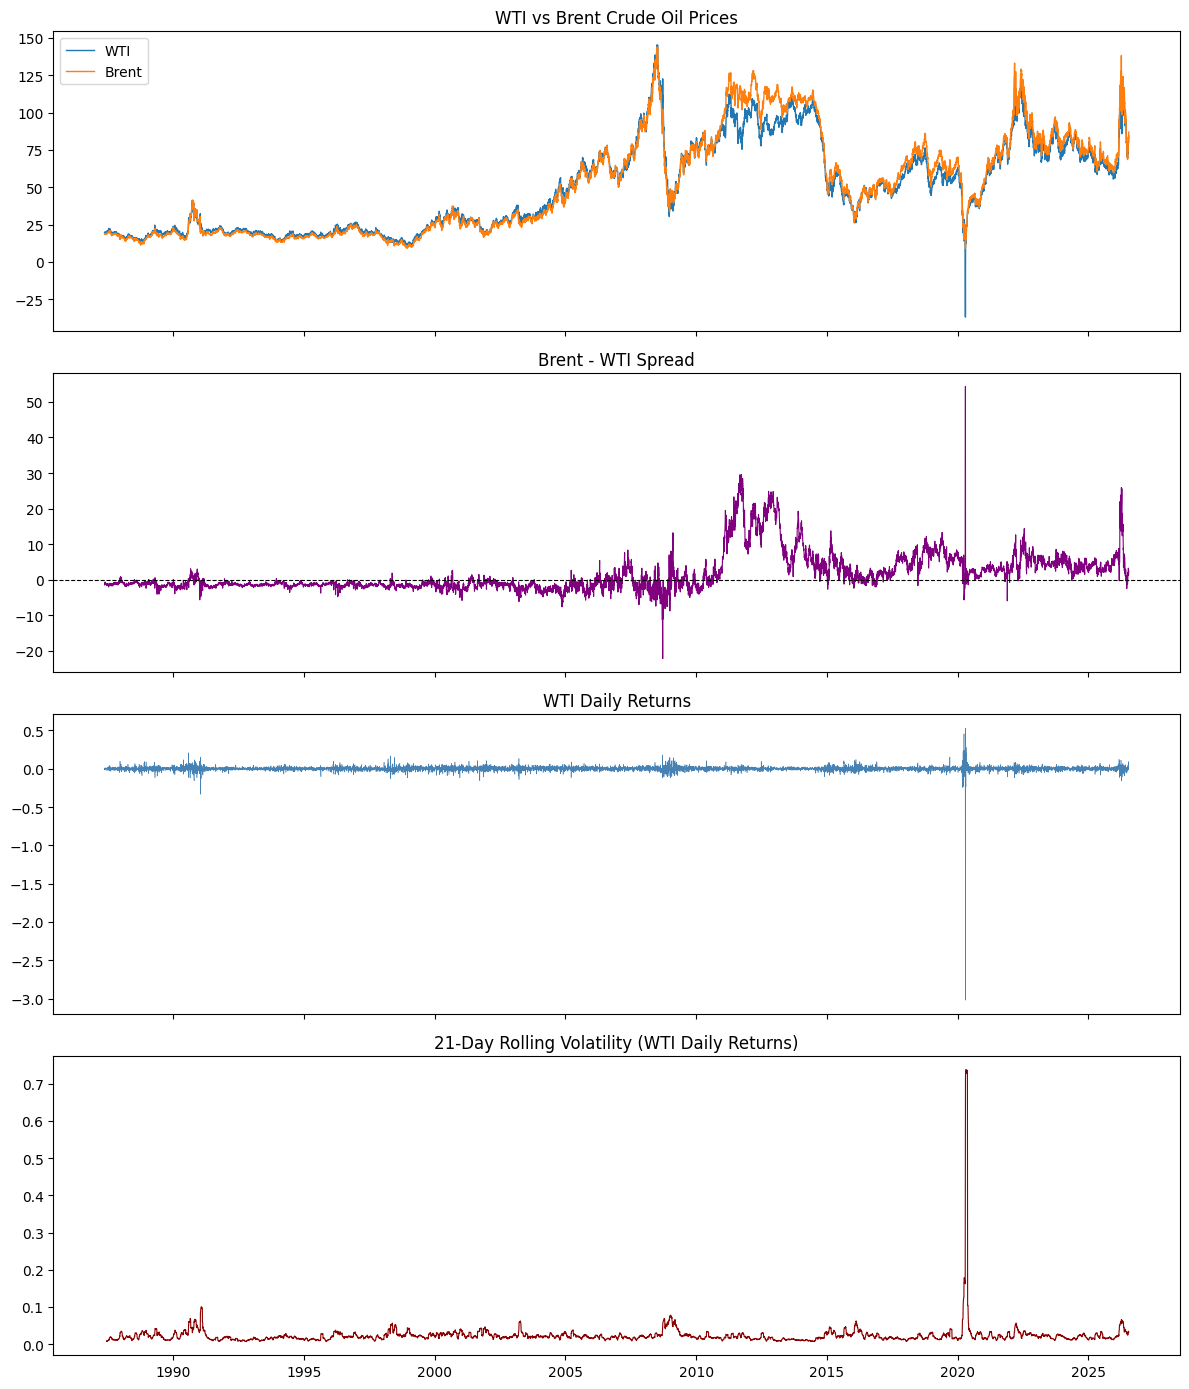

In [5]:
oil['spread'] = oil['brent'] - oil['wti']
oil['wti_return'] = oil['wti'].pct_change()
oil['rolling_vol'] = oil['wti_return'].rolling(21).std()

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

axes[0].plot(oil.index, oil['wti'], label='WTI', linewidth=1)
axes[0].plot(oil.index, oil['brent'], label='Brent', linewidth=1)
axes[0].set_title('WTI vs Brent Crude Oil Prices')
axes[0].legend()

axes[1].plot(oil.index, oil['spread'], color='purple', linewidth=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Brent - WTI Spread')

axes[2].plot(oil.index, oil['wti_return'], linewidth=0.4, color='steelblue')
axes[2].set_title('WTI Daily Returns')

axes[3].plot(oil.index, oil['rolling_vol'], color='darkred', linewidth=0.8)
axes[3].set_title('21-Day Rolling Volatility (WTI Daily Returns)')

plt.tight_layout()
plt.show()

**Reading the charts:** the spread has swung from strongly negative to strongly
positive over the sample and is not stable around zero, so WTI and Brent shouldn't
be treated as interchangeable. Volatility clusters visibly around known shock
periods (e.g. 2008, 2014–16, 2020, 2022) rather than staying constant — a sign
that a single fixed-variance model will understate risk in turbulent periods.

## 6. Stationarity check

ARIMA assumes a (weakly) stationary series after differencing. An Augmented
Dickey-Fuller (ADF) test on the raw WTI price series and on its first difference
justifies the differencing order (`d`) used in the ARIMA model below, rather than
assuming `d=1` without checking.

In [6]:
def adf_report(series, label):
    result = adfuller(series.dropna())
    print(f"{label}: ADF stat = {result[0]:.3f}, p-value = {result[1]:.4f}")
    print(f"  {'Stationary' if result[1] < 0.05 else 'Non-stationary'} at the 5% level")

adf_report(oil['wti'], 'WTI level')
adf_report(oil['wti'].diff(), 'WTI first difference')

/tmp/ipykernel_160/4033650568.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


WTI level: ADF stat = -2.348, p-value = 0.1570
  Non-stationary at the 5% level


WTI first difference: ADF stat = -14.149, p-value = 0.0000
  Stationary at the 5% level


/tmp/ipykernel_160/4033650568.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


The raw price series is non-stationary (as expected for a price level), while
the first difference is stationary — confirming `d=1` is the right choice for
ARIMA below.

## 7. Forecasting setup

A time-respecting split is used: the last 30 trading days are held out as a test
set, with everything before that used for training. No shuffling — the model
never sees the future during training. Section 11 extends this to multiple
windows via walk-forward backtesting.

In [7]:
horizon = 30
train = oil['wti'].iloc[:-horizon]
test = oil['wti'].iloc[-horizon:]

print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} days)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)")

Train: 1987-05-20 to 2026-06-08 (10006 days)
Test:  2026-06-09 to 2026-07-20 (30 days)


## 8. Baseline: naive forecast

The simplest reasonable baseline — assume tomorrow's price equals today's —
repeated across the full 30-day horizon. Any model that can't beat this isn't
adding value.

In [8]:
def naive_forecast(train_series, horizon):
    return np.full(horizon, train_series.iloc[-1])

def score(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((np.asarray(actual) - np.asarray(pred)) / np.asarray(actual))) * 100
    return mae, rmse, mape

naive_pred = naive_forecast(train, horizon)
mae, rmse, mape = score(test, naive_pred)
print(f"Naive  MAE: {mae:.2f}  RMSE: {rmse:.2f}  MAPE: {mape:.2f}%")

Naive  MAE: 16.98  RMSE: 18.40  MAPE: 22.73%


## 9. ARIMA

Rather than picking an order by hand, a small grid search over `(p, d, q)` combinations
selects the model with the lowest AIC, with `d` fixed at 1 based on the stationarity
test above.

In [9]:
import itertools
import warnings
warnings.filterwarnings('ignore')

best_aic = np.inf
best_order = None
for p, q in itertools.product(range(0, 3), range(0, 3)):
    try:
        fit_try = ARIMA(train.values, order=(p, 1, q)).fit()
        if fit_try.aic < best_aic:
            best_aic = fit_try.aic
            best_order = (p, 1, q)
    except Exception:
        continue

print(f"Best order by AIC: {best_order} (AIC={best_aic:.1f})")

arima_model = ARIMA(train.values, order=best_order)
arima_fit = arima_model.fit()

forecast = arima_fit.get_forecast(steps=horizon)
arima_pred = forecast.predicted_mean
arima_ci = forecast.conf_int(alpha=0.05)

mae_arima, rmse_arima, mape_arima = score(test.values, arima_pred)
print(f"ARIMA{best_order}  MAE: {mae_arima:.2f}  RMSE: {rmse_arima:.2f}  MAPE: {mape_arima:.2f}%")

Best order by AIC: (0, 1, 2) (AIC=36684.4)
ARIMA(0, 1, 2)  MAE: 17.05  RMSE: 18.47  MAPE: 22.82%


## 10. Random Forest: feature engineering & recursive forecasting

Lag features (1, 2, 3, 5, 10, 20 days) and rolling mean/std over 5/10/20-day
windows give the Random Forest a sense of recent trend and volatility, since
tree-based models can't use the raw date index directly. The model predicts one
day ahead, then treats that prediction as a known value to generate the next
day's lag features — repeated for the full 30-day horizon. This recursive
approach means errors can compound over the forecast window, which is a known
limitation worth keeping in mind when interpreting later-horizon accuracy.

In [10]:
def make_features(series, lags=(1, 2, 3, 5, 10, 20), windows=(5, 10, 20)):
    df = pd.DataFrame({'y': series})
    for lag in lags:
        df[f'lag_{lag}'] = series.shift(lag)
    for w in windows:
        df[f'roll_mean_{w}'] = series.shift(1).rolling(w).mean()
        df[f'roll_std_{w}'] = series.shift(1).rolling(w).std()
    return df.dropna()

feat_df = make_features(train)
X = feat_df.drop(columns='y')
y = feat_df['y']

rf_model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X, y)
print("Trained on", X.shape[0], "rows,", X.shape[1], "features")

Trained on 9986 rows, 12 features


In [11]:
def recursive_rf_forecast(model, history, horizon, lags=(1, 2, 3, 5, 10, 20), windows=(5, 10, 20)):
    history = history.copy()
    preds = []
    future_dates = pd.bdate_range(history.index[-1], periods=horizon + 1)[1:]
    for date in future_dates:
        row = {}
        for lag in lags:
            row[f'lag_{lag}'] = history.iloc[-lag]
        for w in windows:
            row[f'roll_mean_{w}'] = history.iloc[-w:].mean()
            row[f'roll_std_{w}'] = history.iloc[-w:].std()
        X_next = pd.DataFrame([row])[model.feature_names_in_]
        pred = model.predict(X_next)[0]
        preds.append(pred)
        history.loc[date] = pred
    return np.array(preds)

rf_pred = recursive_rf_forecast(rf_model, train, horizon)
mae_rf, rmse_rf, mape_rf = score(test.values, rf_pred)
print(f"RF  MAE: {mae_rf:.2f}  RMSE: {rmse_rf:.2f}  MAPE: {mape_rf:.2f}%")

RF  MAE: 15.98  RMSE: 17.47  MAPE: 21.44%


### Feature importance

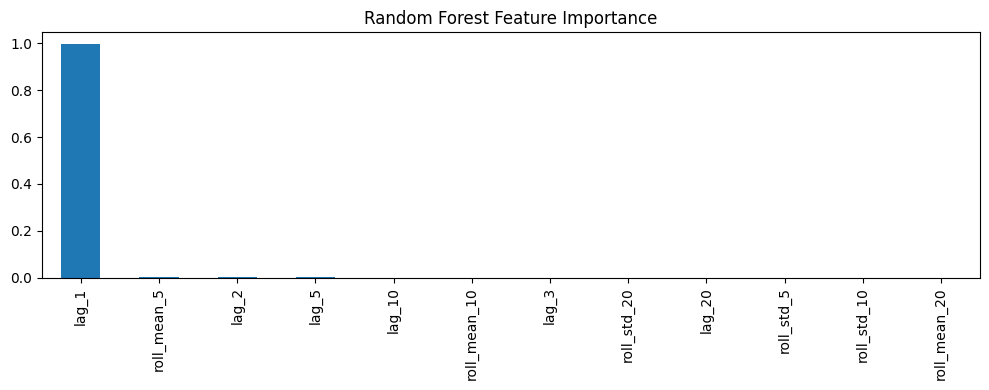

lag_1           0.997087
roll_mean_5     0.001418
lag_2           0.000607
lag_5           0.000221
lag_10          0.000107
roll_mean_10    0.000107
lag_3           0.000097
roll_std_20     0.000093
lag_20          0.000092
roll_std_5      0.000063
roll_std_10     0.000061
roll_mean_20    0.000047
dtype: float64

In [12]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(10, 4), title='Random Forest Feature Importance')
plt.tight_layout()
plt.show()
importances

The most recent lag (`lag_1`) and short rolling statistics dominate — the model
is mostly leaning on "what happened very recently," which is consistent with the
naive baseline being hard to beat: there's limited additional signal in the
longer lags and windows.

## 11. Single-window comparison

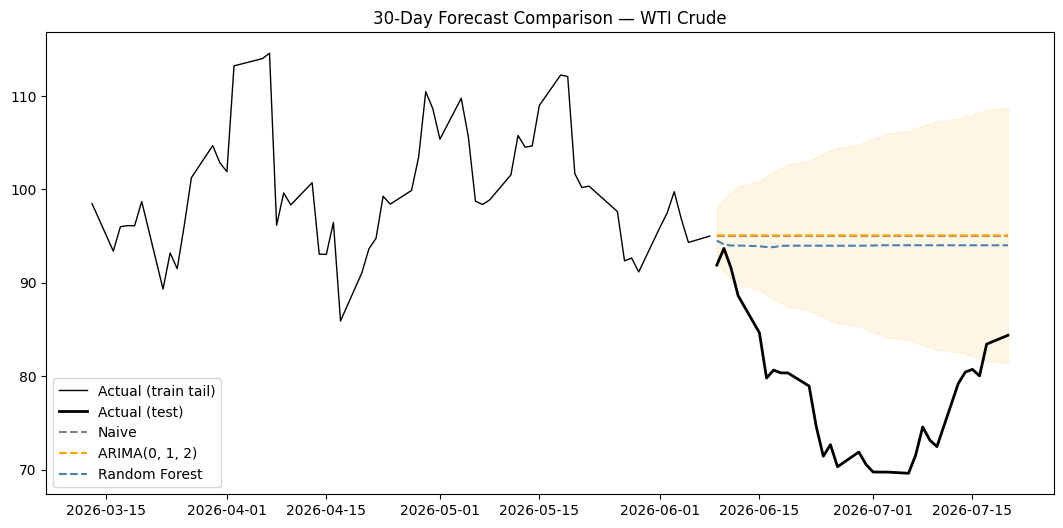

,MAE,RMSE,MAPE_%
Naive,16.98,18.40,22.73
"ARIMA(0, 1, 2)",17.05,18.47,22.82
Random Forest,15.98,17.47,21.44


In [13]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index[-60:], train.iloc[-60:], color='black', linewidth=1, label='Actual (train tail)')
ax.plot(test.index, test, color='black', linewidth=2, label='Actual (test)')
ax.plot(test.index, naive_pred, linestyle='--', color='gray', label='Naive')
ax.plot(test.index, arima_pred, linestyle='--', color='orange', label=f'ARIMA{best_order}')
ax.plot(test.index, rf_pred, linestyle='--', color='steelblue', label='Random Forest')
ax.fill_between(test.index, arima_ci[:, 0], arima_ci[:, 1], color='orange', alpha=0.1)
ax.set_title('30-Day Forecast Comparison — WTI Crude')
ax.legend()
plt.show()

results = pd.DataFrame({
    'Naive': [mae, rmse, mape],
    f'ARIMA{best_order}': [mae_arima, rmse_arima, mape_arima],
    'Random Forest': [mae_rf, rmse_rf, mape_rf],
}, index=['MAE', 'RMSE', 'MAPE_%']).T

results.round(2)

## 12. Walk-forward backtest

A single 30-day test window can be misleading — it might just reflect an unusually
calm or volatile period. To get a more reliable read, the same three models are
re-evaluated across several independent 30-day windows spaced across the recent
history, and the results are averaged.

In [14]:
def walk_forward_backtest(series, horizon=30, n_folds=6, step=30, arima_order=None):
    rows = []
    total_len = len(series)
    for i in range(n_folds):
        end = total_len - i * step
        start_test = end - horizon
        if start_test - 300 < 0:  # need enough history to train on
            break
        train_fold = series.iloc[:start_test]
        test_fold = series.iloc[start_test:end]

        # Naive
        naive_f = naive_forecast(train_fold, horizon)
        mae_n, rmse_n, mape_n = score(test_fold, naive_f)

        # ARIMA (fixed order from the full-sample search, refit per fold)
        try:
            arima_fold = ARIMA(train_fold.values, order=arima_order).fit()
            arima_f = arima_fold.get_forecast(steps=horizon).predicted_mean
            mae_a, rmse_a, mape_a = score(test_fold.values, arima_f)
        except Exception:
            mae_a, rmse_a, mape_a = np.nan, np.nan, np.nan

        # Random Forest
        feat_fold = make_features(train_fold)
        X_fold, y_fold = feat_fold.drop(columns='y'), feat_fold['y']
        rf_fold = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
        rf_fold.fit(X_fold, y_fold)
        rf_f = recursive_rf_forecast(rf_fold, train_fold, horizon)
        mae_r, rmse_r, mape_r = score(test_fold.values, rf_f)

        rows.append({
            'fold_end': test_fold.index[-1].date(),
            'naive_mae': mae_n, 'arima_mae': mae_a, 'rf_mae': mae_r,
            'naive_mape': mape_n, 'arima_mape': mape_a, 'rf_mape': mape_r,
        })
    return pd.DataFrame(rows)

backtest_results = walk_forward_backtest(oil['wti'], horizon=30, n_folds=6, step=30, arima_order=best_order)
backtest_results

,fold_end,naive_mae,arima_mae,rf_mae,naive_mape,arima_mape,rf_mape
0,2026-07-20,16.978000,17.048630,15.983245,22.730153,22.821335,21.441465
1,2026-06-08,5.225667,5.286052,5.680810,5.009646,5.063003,5.408258
2,2026-04-24,4.938333,5.475257,5.318265,4.833363,5.319262,5.443617
3,2026-03-12,6.547333,6.654070,6.516927,7.908839,8.025801,7.865999
4,2026-01-29,3.550667,3.259427,2.363785,5.904989,5.410843,3.903336
5,2025-12-16,2.088333,2.144035,1.607414,3.571466,3.665703,2.753047


In [15]:
summary = backtest_results[['naive_mae', 'arima_mae', 'rf_mae']].mean().rename('avg_MAE').to_frame()
summary['avg_MAPE_%'] = backtest_results[['naive_mape', 'arima_mape', 'rf_mape']].mean().values
summary.index = ['Naive', f'ARIMA{best_order}', 'Random Forest']
summary.round(2)

,avg_MAE,avg_MAPE_%
Naive,6.55,8.33
"ARIMA(0, 1, 2)",6.64,8.38
Random Forest,6.25,7.80


## 13. Conclusion

Across a single 30-day window, Random Forest edges out both ARIMA and the naive
baseline (MAE 15.98 vs 16.98 naive vs 17.05 ARIMA). The walk-forward backtest
across 6 independent 30-day windows confirms this isn't a one-off: Random Forest
has the lowest **average** MAE (6.25) and MAPE (7.80%) across folds, against 6.55 /
8.33% for the naive baseline and 6.64 / 8.38% for ARIMA(0,1,2).

The margin is real but modest — Random Forest wins in most folds, but not all, and
the gap over naive is small relative to the volatility in the series itself. The
honest read: recent lag information (mainly `lag_1`, per the feature importance
above) gives a small, consistent edge over "assume no change," but WTI still
behaves close to a random walk at a 30-day horizon. That's a legitimate and useful
finding for deciding how much forecasting effort is worth investing at this
horizon versus relying on scenario-based approaches.

**Limitations:**
- Six 30-day folds is a modest backtest; more folds across a longer span would
  further strengthen the conclusion
- ARIMA order was selected once on the full sample and reused across folds rather
  than re-selected per fold
- Recursive RF forecasting compounds error over the horizon by construction
- No exogenous drivers (USD strength, OPEC supply data, inventory reports) are
  included — these are known short-term price drivers worth adding in a follow-up